# Forecasting, monitoring, and the direction question (Q2 and Q4)

This notebook covers three connected questions and gives an honest answer to each:

1. **Can we forecast next month's overall Zilretta share better than "same as last month"?** No. Five models were tried; none beat it.
2. **Q2: can a classifier predict next month's direction (Up / Flat / Down)?** No. Three model families were tried; none beat persistence or chance, and with 35 test months the test could only have detected a very large improvement.
3. **Q4: how often do predictions match, and when should a review flag be raised?** The served direction classifier matches about two-thirds of the time; a rolling six-month accuracy of 33% or below is the review line. For the forecast, an interval alarm exists but only catches large jumps in volatility.

Decisions: DL-52 to DL-56. The protocols were fixed in `docs/phase4_modeling_plan.md` before each run.

> The live runs take about 10 minutes.

In [1]:
import shutil
import sys
import tempfile
import time
import warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

from oa_market_intelligence.features.monthly import compute_monthly_features, load_monthly_gold, model_ready_monthly
from oa_market_intelligence.modeling.baselines import (
    MajorityClassBaseline, PersistenceBaseline, SeasonalBaseline, StratifiedRandomBaseline)
from oa_market_intelligence.modeling.direction_models import make_gbm, make_random_forest
from oa_market_intelligence.modeling.evaluation import (
    bootstrap_difference, compare_models, in_sample_scores, mcnemar_exact, score_table, simulate_scores)
from oa_market_intelligence.modeling.forecast import (
    forecast_scores, load_share_series, naive_forecaster, run_task_b, walk_forward_forecast)
from oa_market_intelligence.modeling.models import make_logistic_regression
from oa_market_intelligence.modeling.monitoring import (
    RULES, choose_rule, detection_experiment, direction_backtest, empirical_false_alarm,
    false_alarm_probability, hit_series, interval_misses, random_guess_line, rolling_accuracy,
    stable_threshold, window_alarm, write_backtest_predictions)
from oa_market_intelligence.modeling.power import mcnemar_power, smallest_detectable_gain
from oa_market_intelligence.serving.model_panel import serving_decision

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 160)
engine = create_engine("sqlite:///../data/published/warehouse.db")
series = load_share_series(engine)
print(f"{len(series)} monthly values of Zilretta's visit share (percentage points), {series.index[0]} to {series.index[-1]}; range {series.min():.2f} to {series.max():.2f}")

72 monthly values of Zilretta's visit share (percentage points), 201908 to 202507; range 1.74 to 3.38


# Part A. Forecasting next month's overall share (Task B)

**Setup.** One number per month. For each month from the 25th onward, a model sees only the months before it and forecasts that month, with an 80% and a 90% prediction interval. That gives 48 test months (Aug 2021 to Jul 2025).

**The contenders.**
- *Last month:* the forecast is simply last month's value.
- *Same month last year.*
- *ETS (damped trend):* exponential smoothing, which weights recent months more and lets a trend fade out over time.
- *ETS (damped trend, seasonal):* the same plus a yearly pattern.
- *Ridge regression:* a weighted sum of the last three months and the calendar, with a penalty that keeps the weights small.

**Intervals.** The ETS models give their own intervals; the others use the percentiles of their own past forecast errors.

**The comparison.** Mean absolute error in percentage points, with the paired improvement over the best baseline measured by resampling the 48 months in **blocks of 6** (neighbouring forecast errors are related, so resampling single months would overstate certainty). A model is promoted only if the lower end (1.67th percentile) of its improvement is above zero.

In [2]:
t0 = time.time()
res = run_task_b(series, n_boot=2000, block_length=6, seed=0)
cols = ["mae", "rmse", "mase", "cover80", "cover90", "width80", "width90"]
print(f"run took {time.time()-t0:.0f}s; test months {len(res['forecasts']['last_month'])}; failed model fits: {res['fallbacks']}")
print((res["scores"][cols]).round(3).rename(columns={"mae": "error (pp)", "rmse": "RMSE", "mase": "vs last month's in-sample error", "cover80": "80% interval coverage", "cover90": "90% interval coverage", "width80": "80% width", "width90": "90% width"}).to_string())
print("\nbest baseline:", res["best_baseline"])
for name, s in res["summaries"].items():
    print(f"  {name:13s} improvement over last month {s['estimate']:+.4f} pp, 1.67th percentile {s['low']:+.4f}, share of resamples above zero {s['share_positive']:.3f}")
print("decision:", res["decision"])

run took 18s; test months 48; failed model fits: {'last_month': 0, 'same_month_last_year': 0, 'ets_damped': 0, 'ridge': 0, 'ets_seasonal': 0}
                      error (pp)   RMSE  vs last month's in-sample error  80% interval coverage  90% interval coverage  80% width  90% width
last_month                 0.125  0.157                            0.774                  0.833                  0.958      0.470      0.639
same_month_last_year       0.359  0.422                            2.246                  0.688                  0.729      0.931      1.149
ets_damped                 0.158  0.193                            0.975                  0.750                  0.896      0.492      0.631
ridge                      0.147  0.183                            0.906                  0.771                  0.896      0.511      0.684
ets_seasonal               0.158  0.189                            0.974                  0.708                  0.812      0.383      0.492

best baseli

bootstrap blocks of 3: promoted []; serving last_month


bootstrap blocks of 12: promoted []; serving last_month


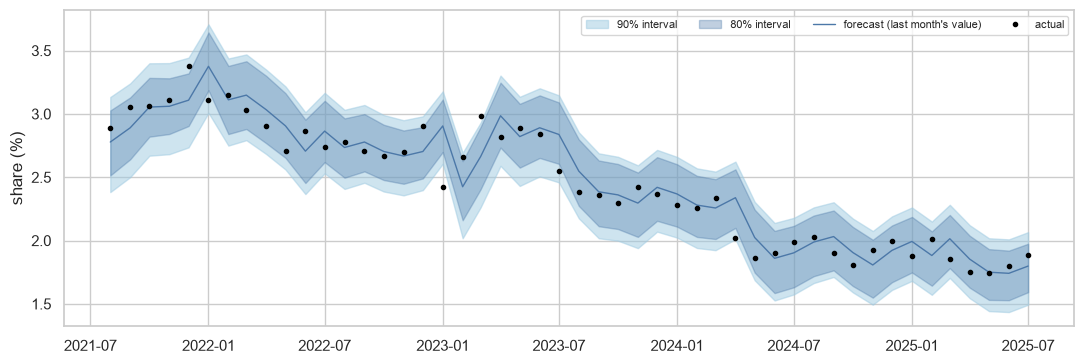

In [3]:
for L in (3, 12):
    r = run_task_b(series, n_boot=2000, block_length=L, seed=0)
    print(f"bootstrap blocks of {L}: promoted {r['decision']['promoted']}; serving {r['decision']['serving']}")
f = res["forecasts"]["last_month"]
fig, ax = plt.subplots(figsize=(11, 3.8))
x = pd.to_datetime(f["month_id"].astype(str), format="%Y%m")
ax.fill_between(x, f["lo90"], f["hi90"], color="#9ecae1", alpha=0.5, label="90% interval")
ax.fill_between(x, f["lo80"], f["hi80"], color="#4c78a8", alpha=0.35, label="80% interval")
ax.plot(x, f["point"], color="#4c78a8", lw=1, label="forecast (last month's value)")
ax.plot(x, f["actual"], "o", color="black", ms=3, label="actual")
ax.set_ylabel("share (%)"); ax.legend(fontsize=8, ncol=4, loc="upper right")
plt.tight_layout(); plt.show()

**What this shows.**

- **None of the trained models beats "same as last month".** Their error is 18% to 27% higher. The ridge result is inconclusive (its interval includes zero), but the rule needs the lower end above zero, so last month serves. The result is the same for bootstrap blocks of 3, 6 and 12 months.
- **Why this is expected.** The share series is very smooth (this month's value is a very good guide to next month's), so extra parameters mostly add estimation noise, and a damped trend overreacts to the turn in 2022.
- **The served forecast's intervals are slightly conservative.** They contain the actual value 83% (80% interval) and 96% (90% interval) of the time. The pre-set band for "close to nominal" is within two binomial standard errors for 48 months (about 68% to 92% for the 80% interval, 81% to 99% for the 90% interval). It missed its 90% interval twice in 48 months (January and March 2023).
- **Plain-language version.** Next month's share is best estimated by this month's, typically within about 0.12 pp (about 5% of the level). The 90% range is about 0.64 pp wide.

# Part B. Q4: monitoring

The question: *how often does the classifier's predicted direction match actual results month to month, and what accuracy threshold should trigger a review flag?* We answer it for the direction classifier as asked, and also build a second monitor for the forecast.

## B1. The direction classifier

In [4]:
bt = direction_backtest(engine)
print(f"{len(bt)} test months ({bt.index.min()} to {bt.index.max()}); class mix {bt['y_true'].value_counts().to_dict()}")
guess = random_guess_line(bt["y_true"].to_numpy(), window=6, n_runs=1000, seed=0)
rows = []
for model in ("seasonal", "persistence", "logistic"):
    hits = hit_series(bt["y_true"], bt[model])
    thr = stable_threshold(hits, window=6, block_length=3, n_boot=2000, seed=0)
    roll = rolling_accuracy(hits, 6)
    rows.append({"classifier": model, "match rate": round(thr["match_rate"], 3), "90% range": f"{thr['rate_low']:.2f} to {thr['rate_high']:.2f}",
                 "review threshold (rolling 6 months)": round(thr["threshold"], 3), "windows at or below it": f"{int((roll <= thr['threshold']).sum())} of {len(roll)}",
                 "windows below the random-guess line": int((roll < guess["line"]).sum())})
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nrandom guessing by class mix: average accuracy {guess['mean_accuracy']:.2f}; 5th percentile of the rolling 6-month accuracy {guess['line']:.2f}")
print(f"always predicting Flat would match {(bt['y_true'] == 'Flat').mean():.0%} of the months")

35 test months (202209 to 202507); class mix {'Flat': 25, 'Down': 6, 'Up': 4}
 classifier  match rate    90% range  review threshold (rolling 6 months) windows at or below it  windows below the random-guess line
   seasonal       0.657 0.49 to 0.77                                0.333                5 of 30                                    0
persistence       0.629 0.49 to 0.74                                0.333                2 of 30                                    0
   logistic       0.400 0.23 to 0.57                                0.000                5 of 30                                    5

random guessing by class mix: average accuracy 0.56; 5th percentile of the rolling 6-month accuracy 0.17
always predicting Flat would match 71% of the months


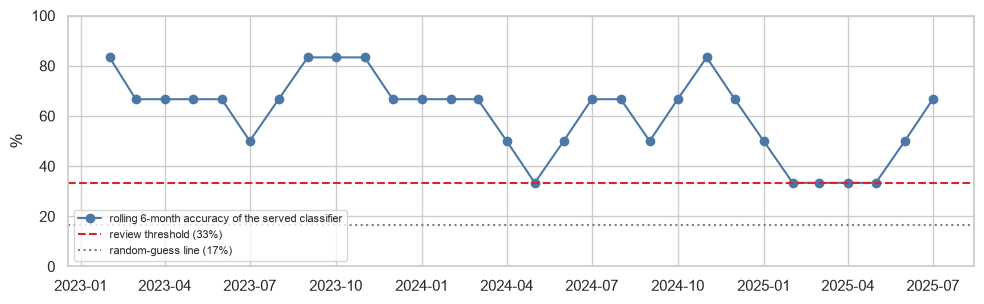

In [5]:
hits = hit_series(bt["y_true"], bt["seasonal"])
roll = rolling_accuracy(hits, 6)
thr = stable_threshold(hits, window=6, block_length=3, n_boot=2000, seed=0)["threshold"]
x = pd.to_datetime(pd.Series(bt.index[5:]).astype(str), format="%Y%m")
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(x, roll * 100, "o-", color="#4c78a8", label="rolling 6-month accuracy of the served classifier")
ax.axhline(thr * 100, color="#d62728", ls="--", label=f"review threshold ({thr*100:.0f}%)")
ax.axhline(guess["line"] * 100, color="gray", ls=":", label=f"random-guess line ({guess['line']*100:.0f}%)")
ax.set_ylim(0, 100); ax.set_ylabel("%"); ax.legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()

**What this shows.**

- The served classifier (the seasonal rule) matched the actual direction in 23 of 35 months (66%, 90% range 49% to 77%). Persistence matched 63%, logistic regression 40%.
- **The match rate alone is misleading.** Always predicting "Flat" would match 71% of the months, more than the served rule's 66%. That is why the project judges classifiers on balanced accuracy, which gives rare classes their due.
- **The review flag.** Raise it when the rolling six-month match rate falls to **33% (2 of 6 months) or below**: the 5th percentile of how low the accuracy dips by chance when performance is stable. A stricter line sits at 17% (what random guessing produces).
- **A caution.** In the backtest the 33% line was reached in 5 of the 30 six-month windows, in two episodes, because hits come in runs. And since the classifier has no skill beyond the baselines, a flag means "worse than its own history", not "the model was ever good".

## B2. A second monitor for the forecast

The served forecast is last month's value with prediction intervals, so a natural monitor asks: *are the actual values falling outside the intervals more often than they should?* Two rules were fixed in advance:

- **R90:** at least 3 of the last 6 months outside the 90% interval.
- **R80:** at least 4 of the last 6 months outside the 80% interval.

If an interval were perfectly calibrated, each would give a false alarm in about 1.6% to 1.7% of six-month windows. They are compared on the real backtest, on the false-alarm rate from resampling the real miss record, and on how fast they detect **simulated** degradation: extra noise added to the series from a start month (volatility), or a steady drift subtracted from it. A rule is only eligible if it raises no alarm in the real backtest; among eligible rules the better detector is chosen. (About a minute.)

In [6]:
fc = walk_forward_forecast(series, naive_forecaster, min_train=24)
alarms = {}
rows = []
for name, rule in RULES.items():
    miss = interval_misses(fc, rule["level"]).to_numpy()
    a = window_alarm(miss, k=rule["k"], n=rule["n"])
    alarms[name] = int(a.sum())
    emp = empirical_false_alarm(miss, k=rule["k"], n=rule["n"], block_length=3, n_boot=2000, seed=0)
    nominal = false_alarm_probability(1 - float(rule["level"]) / 100, rule["k"], rule["n"])
    rows.append({"rule": name, "months outside the interval": f"{int(miss.sum())} of {len(miss)}", "alarm windows in the real backtest": f"{int(a.sum())} of {len(a)}",
                 "false alarms per window if calibrated": f"{nominal:.2%}", "false alarms per window, from the real misses": f"{emp:.2%}"})
print(pd.DataFrame(rows).to_string(index=False))
print("months outside the 90% interval:", fc.loc[interval_misses(fc, "90"), "month_id"].tolist())
print("months outside the 80% interval:", fc.loc[interval_misses(fc, "80"), "month_id"].tolist())
t0 = time.time()
det = detection_experiment(series, n_seeds=20, seed=0)
print(f"\ndetection within 6 months of the start of a simulated degradation ({det['n_starts'].iloc[0]} start months; {time.time()-t0:.0f}s)")
print(det.pivot(index="scenario", columns="rule", values=["detection_rate", "median_delay"]).round(2).to_string())
choice = choose_rule(det, alarms)
print("\nrule chosen by the pre-set criterion:", choice["rule"], "| average detection:", {k: round(v, 3) for k, v in choice["average_detection"].items()})

rule months outside the interval alarm windows in the real backtest false alarms per window if calibrated false alarms per window, from the real misses
 R90                     2 of 48                            0 of 43                                 1.58%                                         0.41%
 R80                     8 of 48                            3 of 43                                 1.70%                                         3.31%
months outside the 90% interval: [202301, 202303]
months outside the 80% interval: [202112, 202201, 202212, 202301, 202302, 202303, 202307, 202404]



detection within 6 months of the start of a simulated degradation (37 start months; 69s)
                detection_rate       median_delay     
rule                       R80   R90          R80  R90
scenario                                              
drift 0.1                 0.14  0.00          1.0  NaN
drift 0.2                 0.24  0.00          1.0  NaN
drift 0.3                 0.43  0.24          2.5  3.0
volatility 0.15           0.23  0.14          2.0  3.0
volatility 0.30           0.56  0.54          3.0  3.0

rule chosen by the pre-set criterion: R90 | average detection: {'R80': 0.321, 'R90': 0.183}


**What this shows.**

- **R90 is chosen.** R80 detects more, but it raised alarms in the real backtest (the swings of December 2022 to March 2023), and the rule says a candidate must raise none.
- **R90 is conservative and insensitive.** It has about 0.4% false alarms per window (much lower than 1.6%, because the real intervals are conservative), but it only reliably catches large jumps: about 54% of the time within 6 months for noise twice as large as normal, around 14% for noise half that size, and **it does not catch a steady drift of 0.2 pp a month or less**.
- **Two honest limits.** The real decline since 2022 runs at about 0.03 pp a month, so this alarm would never have seen it. And a forecast that always uses last month's value adapts to a level shift after one month, so an interval alarm is blind to level shifts by design. A cumulative-sum monitor for slow drift would be a natural addition; it has not been built.

## B3. Recording the backtest in the warehouse

The Gold table has empty placeholder columns for predictions. The function below fills them on a **temporary copy** of the database (the real database is not touched here): row *m* holds the prediction made with data through month *m* for month *m+1*, together with that month's actual direction, and a label marking it as a backtest. The publish step will call the same function (Step 14).

In [7]:
tmp = tempfile.mkdtemp()
copy = f"{tmp}/warehouse_copy.db"
shutil.copyfile("../data/published/warehouse.db", copy)
eng = create_engine(f"sqlite:///{copy.replace(chr(92), '/')}")
frame = pd.DataFrame({"month_id": bt.index, "predicted": bt["seasonal"].to_numpy(), "actual": bt["y_true"].to_numpy(), "probability": np.nan})
write_backtest_predictions(eng, frame, "backtest walk-forward: seasonal rule")
with eng.connect() as conn:
    filled = conn.execute(text("SELECT COUNT(*) FROM gold_visit_share_monthly WHERE predicted_direction IS NOT NULL")).scalar()
    check = pd.read_sql("SELECT a.month_id, a.actual_direction, b.direction_label FROM gold_visit_share_monthly a JOIN gold_visit_share_monthly b ON b.month_id = (SELECT MIN(month_id) FROM gold_visit_share_monthly WHERE month_id > a.month_id) WHERE a.actual_direction IS NOT NULL", conn)
    tail = pd.read_sql("SELECT month_id, direction_label, predicted_direction, actual_direction FROM gold_visit_share_monthly ORDER BY month_id DESC LIMIT 3", conn)
print(f"{filled} rows filled; each row's actual_direction equals the next month's direction_label for all of them: {bool((check['actual_direction'] == check['direction_label']).all())}")
print(tail.to_string(index=False))

35 rows filled; each row's actual_direction equals the next month's direction_label for all of them: True
 month_id direction_label predicted_direction actual_direction
   202507            Flat                 NaN              NaN
   202506            Flat                Flat             Flat
   202505            Flat                Flat             Flat


# Part C. Q2: can a classifier predict next month's direction?

**The task.** Each month is labelled Up, Flat or Down according to how unusual that month's change in share was compared with the previous 12 months' changes. Of the 72 months of data, the first 13 cannot be labelled (the label needs the earlier changes), leaving **59 labelled months**; after the first 24 are kept as the minimum training window, **35 months are tested** (25 Flat, 6 Down, 4 Up).

**The contenders.** Four simple baselines (always the most common class, last month's direction, a seasonal rule, random guessing by class mix) and three trained models on the same 22 features: logistic regression, **random forest** and **gradient boosting**. The last two were added so Q2 is answered with the model families the assignment names; each chooses its own settings inside every training window.

**The serving rule (fixed earlier, DL-32).** A trained model is served only if its balanced accuracy is strictly above both the 95th percentile of what random guessing produces *and* every baseline. Otherwise the best baseline serves. (About 5 minutes.)

In [8]:
ready = model_ready_monthly(compute_monthly_features(load_monthly_gold(engine)))
print(f"{len(ready)} labelled months, {ready.shape[1]-1} features; classes {ready['direction_label'].value_counts().to_dict()}")
models = {"always-majority": MajorityClassBaseline, "persistence": PersistenceBaseline, "seasonal": SeasonalBaseline,
          "logistic": make_logistic_regression, "random forest": make_random_forest, "gradient boosting": make_gbm}
t0 = time.time()
preds = compare_models(ready, models, min_train=24)
print(f"walk-forward took {time.time()-t0:.0f}s over {len(preds)} test months")
scores = score_table(preds)
print(scores[["accuracy", "balanced_accuracy", "macro_f1", "recall_down", "recall_up"]].round(3).to_string())
chance = simulate_scores(ready, lambda s: (lambda: StratifiedRandomBaseline(s)), range(1000), min_train=24)
p95 = float(chance["balanced_accuracy"].quantile(0.95))
print(f"\nrandom guessing (1,000 runs): balanced accuracy averages {chance['balanced_accuracy'].mean():.3f}; 95th percentile {p95:.3f}")
print("serving decision:", serving_decision(scores[["balanced_accuracy"]].rename(index={"random forest": "rf", "gradient boosting": "gbm"}), chance_p95=p95)["reason"])

59 labelled months, 22 features; classes {'Flat': 43, 'Down': 9, 'Up': 7}


walk-forward took 269s over 35 test months
                   accuracy  balanced_accuracy  macro_f1  recall_down  recall_up
always-majority       0.714              0.333     0.278        0.000       0.00
persistence           0.629              0.406     0.406        0.167       0.25
seasonal              0.657              0.419     0.429        0.167       0.25
logistic              0.400              0.369     0.319        0.167       0.50
random forest         0.457              0.326     0.315        0.167       0.25
gradient boosting     0.629              0.406     0.406        0.167       0.25



random guessing (1,000 runs): balanced accuracy averages 0.325; 95th percentile 0.461
serving decision: gbm (balanced accuracy 0.406) is not above the range chance produces (random guessing, 95th percentile 0.461), so it is not promoted; the best baseline (seasonal) serves.


In [9]:
print("paired comparison with persistence (balanced accuracy, 95% interval, blocks of 3) and McNemar's exact test on the months where exactly one is right")
for m in ("logistic", "random forest", "gradient boosting", "seasonal"):
    b = bootstrap_difference(preds["y_true"], preds[m], preds["persistence"], metric="balanced_accuracy", n_boot=2000, seed=0, level=0.95, block_length=3)
    mc = mcnemar_exact(preds["y_true"], preds[m], preds["persistence"])
    print(f"  {m:18s} minus persistence {b['point']:+.3f} [{b['lo']:+.3f}, {b['hi']:+.3f}] | only {m} right in {mc['a_only_correct']} months, only persistence right in {mc['b_only_correct']} | p = {mc['p_value']:.3f}")
print("\noverfitting check: balanced accuracy on the months the model trained on vs on the months it was tested on")
for name, make in (("logistic", make_logistic_regression), ("random forest", make_random_forest), ("gradient boosting", make_gbm)):
    ins = in_sample_scores(ready, make, min_train=24)
    print(f"  {name:18s} trained-on {ins['train_balanced_accuracy'].mean():.3f}   tested {scores.loc[name, 'balanced_accuracy']:.3f}")

paired comparison with persistence (balanced accuracy, 95% interval, blocks of 3) and McNemar's exact test on the months where exactly one is right


  logistic           minus persistence -0.037 [-0.388, +0.296] | only logistic right in 5 months, only persistence right in 13 | p = 0.096


  random forest      minus persistence -0.080 [-0.270, +0.109] | only random forest right in 2 months, only persistence right in 8 | p = 0.109


  gradient boosting  minus persistence +0.000 [-0.318, +0.338] | only gradient boosting right in 5 months, only persistence right in 5 | p = 1.000


  seasonal           minus persistence +0.013 [-0.288, +0.354] | only seasonal right in 7 months, only persistence right in 6 | p = 1.000

overfitting check: balanced accuracy on the months the model trained on vs on the months it was tested on


  logistic           trained-on 0.857   tested 0.369


  random forest      trained-on 0.922   tested 0.326


  gradient boosting  trained-on 0.996   tested 0.406


**What this shows.**

- **No trained model clears the rule.** Balanced accuracy: seasonal rule 0.419 (it serves), persistence 0.406, gradient boosting 0.406, logistic regression 0.369, random forest 0.326, against a chance 95th percentile of 0.461.
- **Gradient boosting equals persistence month for month** (right in 5 months where persistence was wrong, wrong in 5 where it was right). Logistic and random forest are worse, though not significantly so.
- **All three overfit badly.** On the months they trained on they score 0.86 to 1.00; on new months 0.33 to 0.41. They memorise what they have seen and learn nothing that carries over.

## What could a test this small have detected? (the power statement)

"No signal found" can mean "there is none" or "there is some but we cannot see it". To tell which, simulate: take persistence's accuracy (22 of 35 right), imagine a better classifier whose accuracy is higher by some amount, keep the rate at which the two disagree in correctness equal to what was observed between persistence and the seasonal rule (37% of months), and count how often McNemar's exact test would flag the improvement.

persistence is right in 22 of 35 months (62.9%); it differs in correctness from the seasonal rule in 37.1% of months
smallest accuracy gain over persistence detected with 80% power: 0.3


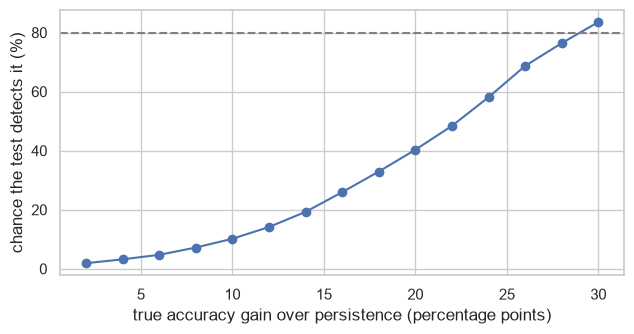

gain (points)        2.0  4.0  6.0  8.0  10.0  12.0  14.0  16.0  18.0  20.0  22.0  24.0  26.0  28.0  30.0
chance detected (%)  2.0  3.0  5.0  7.0  10.0  14.0  19.0  26.0  33.0  40.0  48.0  58.0  69.0  76.0  84.0


In [10]:
hp, hs = hit_series(preds["y_true"], preds["persistence"]), hit_series(preds["y_true"], preds["seasonal"])
acc_p, disc = float(hp.mean()), float((hp != hs).mean())
tab = mcnemar_power(n=len(preds), accuracy=acc_p, discordance=disc, deltas=np.round(np.arange(0.02, 0.31, 0.02), 2), n_sim=5000, seed=0)
print(f"persistence is right in {int(hp.sum())} of {len(hp)} months ({acc_p:.1%}); it differs in correctness from the seasonal rule in {disc:.1%} of months")
print("smallest accuracy gain over persistence detected with 80% power:", smallest_detectable_gain(tab, power=0.8))
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(tab["delta"] * 100, tab["power"] * 100, "o-"); ax.axhline(80, color="gray", ls="--")
ax.set_xlabel("true accuracy gain over persistence (percentage points)"); ax.set_ylabel("chance the test detects it (%)")
plt.tight_layout(); plt.show()
print(tab.assign(delta=(tab["delta"] * 100).round(0), power=(tab["power"] * 100).round(0)).rename(columns={"delta": "gain (points)", "power": "chance detected (%)"})[["gain (points)", "chance detected (%)"]].T.to_string(header=False))

**What this shows.** The smallest gain this test could detect with 80% power is about **30 percentage points** (from 63% to about 93% accuracy). A gain of 10 points would be detected about 10% of the time, and 20 points about 40% of the time. So the honest statement is: *three model families found no reliable direction signal, and a test this small could only have shown a very large one.* It does not show that direction is impossible to predict.

## What this means, and what it does not

**Supported:**
- Next month's overall share is best estimated by this month's (error about 0.12 pp, 90% range about 0.64 pp wide); five alternatives were tried and none is better.
- Direction (Up / Flat / Down) is not predictable with these 59 labelled months: not by a baseline, a logistic regression, a random forest or gradient boosting.
- A review flag for the direction classifier at a rolling six-month accuracy of 33% or below, and an interval alarm for the forecast that almost never raises a false alarm.

**Not supported:**
- That prediction is impossible. The power statement says what the data cannot resolve.
- That the alarm monitors model decay in general: it catches large jumps in volatility, not slow drift or level shifts.
- Anything about RA, which has too few visits (about 1,283 in six years) to monitor.

**What would help:** a longer history (so a modest effect becomes detectable), and extra inputs the warehouse does not hold, such as payer or formulary changes, geography, price and prescription volume.